<a href="https://colab.research.google.com/github/ACM-Research/paperImplementationsS25/blob/Jagadeep/Malicious_URL_Detection_Colab_20250606_212703.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malicious URL Detection Using Machine Learning (Colab-Compatible Implementation)
**Based on:** _"Malicious URL Detection Using Machine Learning" by Cho Do Xuan et al._

In [1]:
# Step 1: Install dependencies
!pip install -q pandas scikit-learn matplotlib seaborn

In [2]:
# Step 2: Import necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [4]:
# Step 3: Load a dataset (Kaggle: https://www.kaggle.com/datasets/antonyj453/urldataset)
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('data.csv')  # Ensure you upload this CSV manually

Saving data.csv to data (1).csv


In [5]:
# Step 4: Basic preprocessing
df = df[['url', 'label']]
df = df.sample(frac=1).reset_index(drop=True)

# Reduce dataset size for faster testing
df = df.sample(n=10000, random_state=42)

In [6]:
# Step 5: Feature engineering + vectorization
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 4), max_features=5000)
X = tfidf.fit_transform(df['url'])
y = df['label']

In [7]:
# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Step 7: Model training (optimized for speed)
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [9]:
# Step 8: Prediction and evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.937

Classification Report:
               precision    recall  f1-score   support

         bad       0.89      0.72      0.80       344
        good       0.94      0.98      0.96      1656

    accuracy                           0.94      2000
   macro avg       0.92      0.85      0.88      2000
weighted avg       0.94      0.94      0.93      2000



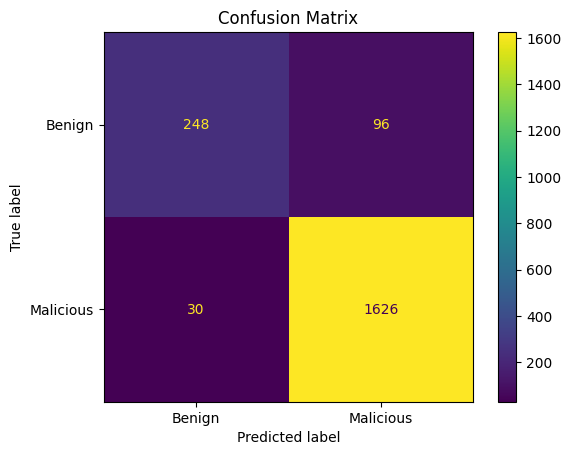

In [10]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malicious']).plot()
plt.title('Confusion Matrix')
plt.show()

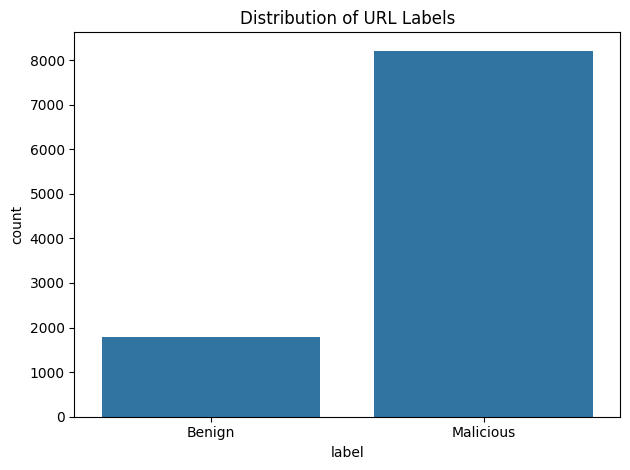

In [11]:
# Step 10: Visualization - Class Distribution
sns.countplot(data=df, x='label')
plt.title("Distribution of URL Labels")
plt.xticks(ticks=[0, 1], labels=['Benign', 'Malicious'])
plt.tight_layout()
plt.show()

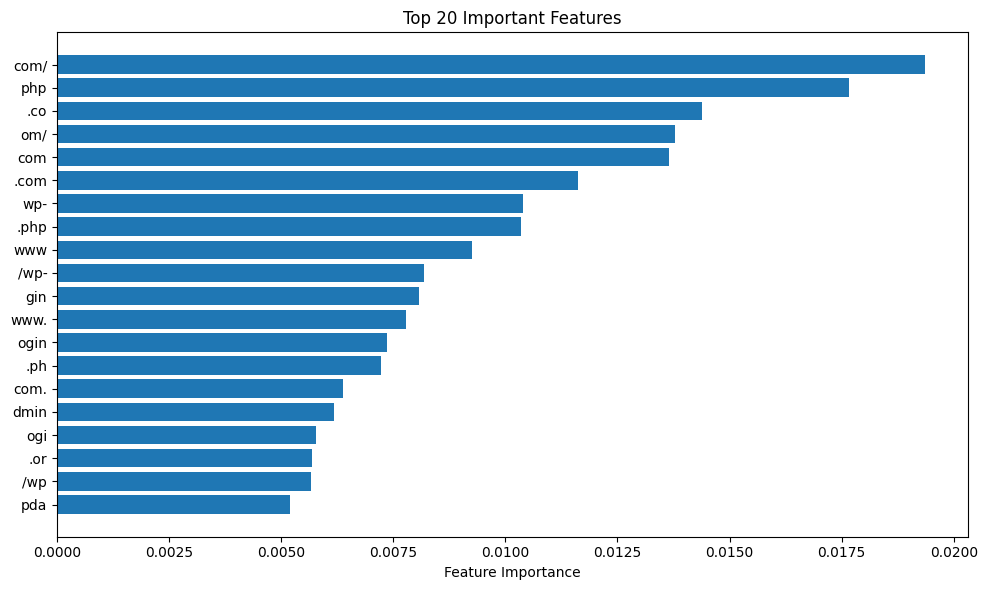

In [12]:
# Step 11: Visualization - Feature Importance (top 20)
importances = model.feature_importances_
indices = np.argsort(importances)[-20:][::-1]
feature_names = np.array(tfidf.get_feature_names_out())
plt.figure(figsize=(10, 6))
plt.title("Top 20 Important Features")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()